In [1]:
import pandas as pd
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv('Advertising.csv')
df.head(6)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2


In [3]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [4]:
x = df[['TV', 'Radio', 'Newspaper']]

In [5]:
y = df['Sales']

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=15)

In [7]:
print(x_train.shape)

(160, 3)


In [8]:
print(x_test.shape)

(40, 3)


In [9]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()

In [10]:
LR.fit(x_train.values,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.06,0.1 ,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.403
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[1055.53, 290.03, 165.4 ]"


In [11]:
LR.intercept_

np.float64(4.403301064986735)

In [12]:
LR.coef_

array([0.05579385, 0.10182203, 0.00415545])

In [13]:
print("The LR model is: Y = ",LR.intercept_, "+", LR.coef_[0], "TV + ", LR.coef_[1], "radio + ", LR.coef_[2], "newspaper")

The LR model is: Y =  4.403301064986735 + 0.05579385181816195 TV +  0.1018220299202035 radio +  0.004155447835227241 newspaper


In [14]:
advertisment = [[120, 50, 60]]

pred = LR.predict(advertisment)
print("prediction= ", pred[0])

prediction=  16.438991649289978


In [15]:
y_pred = LR.predict(x_test.values)
y_pred

array([ 9.48014798,  9.74034749,  9.578992  ,  7.61412598,  8.9161981 ,
       18.10349948, 23.80639906,  8.45058944,  9.52481395, 14.02638709,
        5.91173779,  9.33890342, 21.63371306, 18.5788581 , 21.3716781 ,
       15.41198661, 15.90374543, 12.37618248, 20.85725333, 24.77805334,
        8.8089096 , 23.77526226,  9.57401827, 18.23968951, 18.18553619,
       13.03492642, 23.14573163,  9.20376162, 15.20778442, 18.26570686,
        6.28886805, 21.79104406,  9.8413285 , 12.11724872, 19.19663564,
       10.32455902, 11.52696495, 13.73223973, 22.41892146,  7.04160649])

<Axes: xlabel='Sales'>

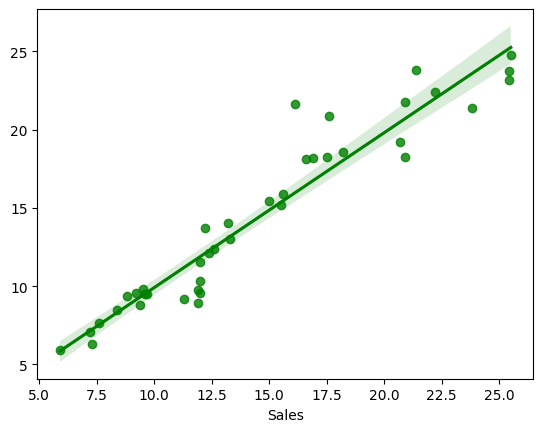

In [16]:
sns.regplot(x = y_test, y = y_pred, color='green')

In [17]:
from sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(y_test,y_pred)
mse = metrics.mean_squared_error(y_test,y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test,y_pred))

In [19]:
print('mae =', round(mae, 2))
print('mse =', round(mse, 2))
print('rmse =', round(rmse, 2))

mae = 1.17
mse = 2.71
rmse = 1.65
